# Craft a Story from a Dataset
## Longer Lives, Uneven Progress: A Global Development Story from Gapminder

Chosen audience: Executive leadership at a global health or development nonprofit  
Dataset: Gapminder country-level data from 1952 to 2007  
Central story: People around the world are living much longer than they did in 1952, but progress has not been equally shared. Wealth and life expectancy move together, yet income alone does not explain every outcome.

## 1. Why this dataset and this audience?

I chose the Gapminder dataset because it is ideal for storytelling:
- it has a clear time component,
- it supports comparisons across countries and continents,
- it contains a compelling relationship between prosperity and health,
- and it is clean enough that the focus can stay on insight rather than data cleaning.

For an executive audience, the goal is not to overwhelm with technical detail. Instead, the notebook emphasizes:
1. the main trend,
2. where the trend is uneven,
3. what factors appear related to the outcome,
4. and what practical decisions or questions should come next.

## 2. Questions I asked

1. **How much has global life expectancy changed over time?**  
2. **Has every continent benefited equally from that progress?**  
3. **How closely is income tied to life expectancy?**  
4. **Which countries made the biggest gains, and what does that suggest?**  
5. **What is the clearest takeaway for a non-technical decision-maker?**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("gapminder.csv")

df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## 3. First look at the data

Before telling a story, it helps to understand the shape of the dataset:
- one row per country-year observation,
- data from 1952 to 2007,
- and variables that support both trend analysis and comparisons: life expectancy, GDP per capita, population, country, continent, and year.

In [2]:
summary = {
    "rows": len(df),
    "columns": df.shape[1],
    "countries": df["country"].nunique(),
    "continents": df["continent"].nunique(),
    "years": f'{df["year"].min()} to {df["year"].max()}'
}
pd.Series(summary)

rows                  1704
columns                  8
countries              142
continents               5
years         1952 to 2007
dtype: object

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,1704,142,Afghanistan,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,1704,5,Africa,624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1704.0,NaN,NaN,NaN,1979.5,17.26533,1952.0,1965.75,1979.5,1993.25,2007.0
lifeExp,1704.0,NaN,NaN,NaN,59.474439,12.917107,23.599,48.198,60.7125,70.8455,82.603
pop,1704.0,NaN,NaN,NaN,29601212.324531,106157896.743915,60011.0,2793664.0,7023595.5,19585221.75,1318683096.0
gdpPercap,1704.0,NaN,NaN,NaN,7215.327081,9857.454543,241.165876,1202.060309,3531.846989,9325.462346,113523.1329
iso_alpha,1704,141,KOR,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iso_num,1704.0,NaN,NaN,NaN,425.880282,248.305709,4.0,208.0,410.0,638.0,894.0


## 4. Trend 1: The world made major gains in life expectancy

To tell a global story, I calculated population-weighted life expectancy by year. Weighting by population matters here because it better reflects the experience of the world's population, not just the average across countries.

From 1952 to 2007, global population-weighted life expectancy rose from 48.9 years to 68.9 years — a gain of about 20.0 years.

/tmp/ipykernel_2863/3464020601.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["lifeExp"], weights=x["pop"]))


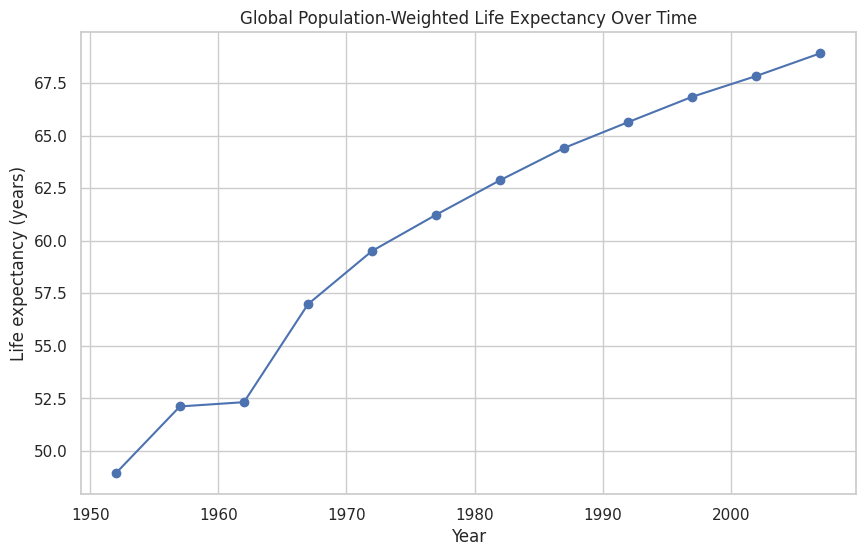

,year,weighted_lifeExp
0,1952,48.944237
1,1957,52.121885
2,1962,52.324382
3,1967,56.984307
4,1972,59.514783
5,1977,61.237256
6,1982,62.881755
7,1987,64.416350
8,1992,65.645900
9,1997,66.849343


In [4]:
global_life = (
    df.groupby("year")
      .apply(lambda x: np.average(x["lifeExp"], weights=x["pop"]))
      .reset_index(name="weighted_lifeExp")
)

fig, ax = plt.subplots()
ax.plot(global_life["year"], global_life["weighted_lifeExp"], marker="o")
ax.set_title("Global Population-Weighted Life Expectancy Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
plt.show()

global_life

A line chart tells us the main story quickly: global longevity improved dramatically across the second half of the twentieth century. That is the broad success story.

But averages can hide inequality, so the next step is to check whether all regions moved forward in the same way.

## 5. Trend 2: Progress was real, but not evenly distributed

A global average can make the world look more uniform than it really is. To understand uneven progress, I compared population-weighted life expectancy across continents over time.

/tmp/ipykernel_2863/3350968256.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["lifeExp"], weights=x["pop"]))


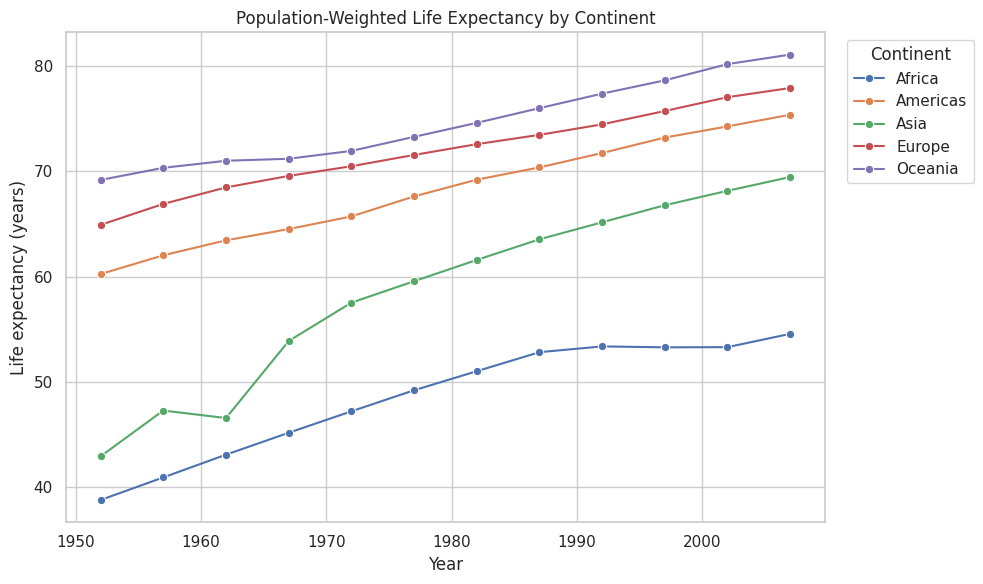

In [5]:
continent_life = (
    df.groupby(["year", "continent"])
      .apply(lambda x: np.average(x["lifeExp"], weights=x["pop"]))
      .reset_index(name="weighted_lifeExp")
)

fig, ax = plt.subplots()
sns.lineplot(data=continent_life, x="year", y="weighted_lifeExp", hue="continent", marker="o", ax=ax)
ax.set_title("Population-Weighted Life Expectancy by Continent")
ax.set_xlabel("Year")
ax.set_ylabel("Life expectancy (years)")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

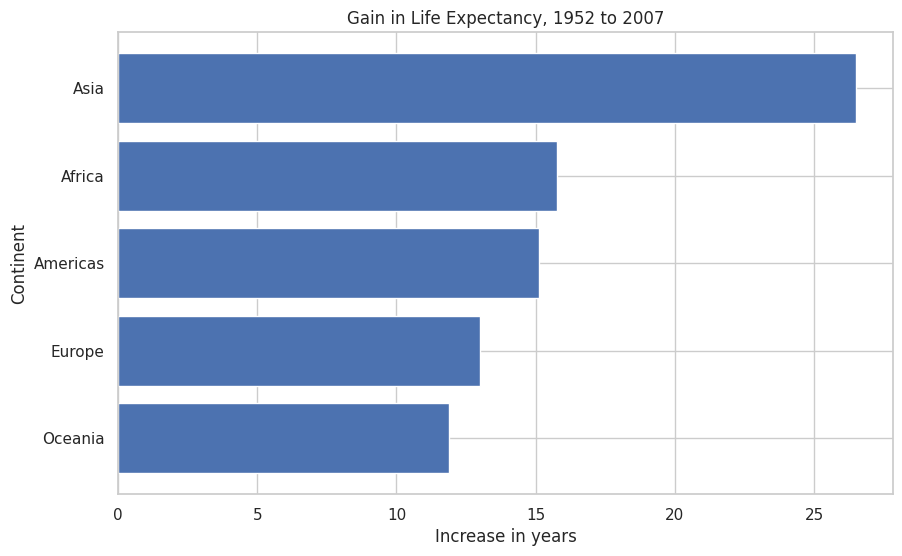

year,gain
continent,
Oceania,11.89
Europe,12.99
Americas,15.12
Africa,15.76
Asia,26.50


In [6]:
continent_change = (
    continent_life.pivot(index="continent", columns="year", values="weighted_lifeExp")
    .assign(gain=lambda x: x[2007] - x[1952])
    .sort_values("gain", ascending=True)
)

fig, ax = plt.subplots()
ax.barh(continent_change.index, continent_change["gain"])
ax.set_title("Gain in Life Expectancy, 1952 to 2007")
ax.set_xlabel("Increase in years")
ax.set_ylabel("Continent")
plt.show()

continent_change[["gain"]].round(2)

The continent view adds an important nuance:
- Asia saw the largest gain, about 26.5 years.
- Oceania also improved, but by a smaller 11.9 years.

So the story is not just "people live longer now." The fuller story is: people live longer almost everywhere, but some regions advanced much faster than others.

## 6. Trend 3: Wealth and life expectancy are strongly related

A common hypothesis in development work is that higher income is associated with longer life expectancy. The Gapminder data lets us test that visually and numerically.

For readability, I use a log scale on GDP per capita. That matters because income spans a very wide range across countries.

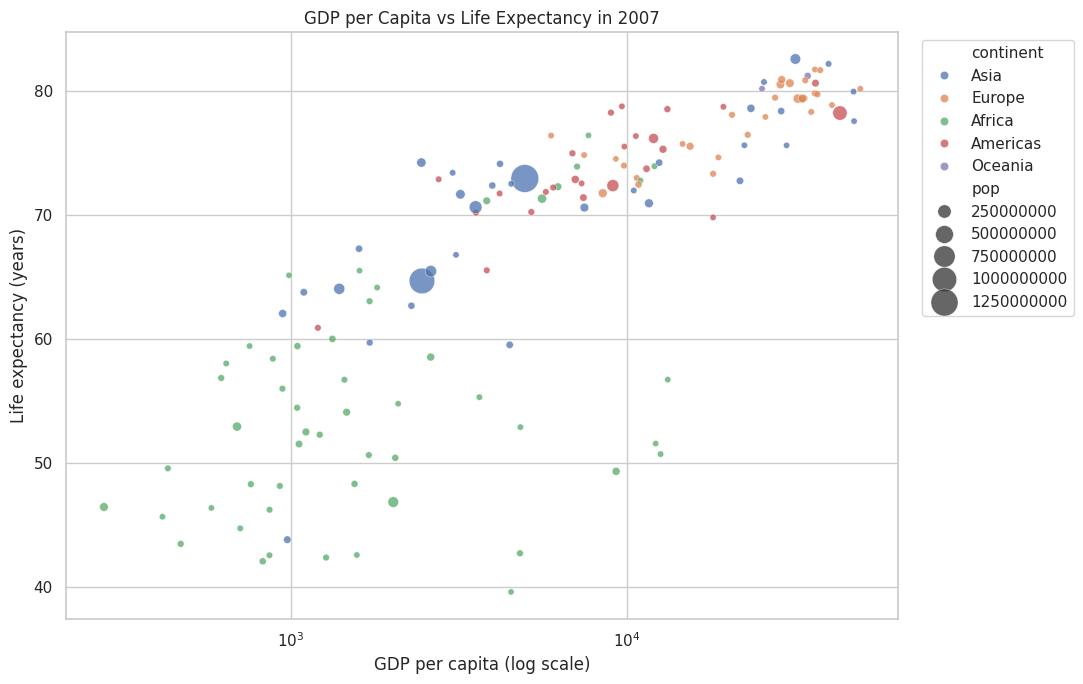

Pearson correlation between log10(GDP per capita) and life expectancy: 0.809 (p = 4.12e-34)
Spearman correlation between GDP per capita and life expectancy: 0.857 (p = 4.62e-42)


In [7]:
df_2007 = df[df["year"] == 2007].copy()
df_2007["log_gdpPercap"] = np.log10(df_2007["gdpPercap"])

pearson_r, pearson_p = pearsonr(df_2007["log_gdpPercap"], df_2007["lifeExp"])
spearman_rho, spearman_p = spearmanr(df_2007["gdpPercap"], df_2007["lifeExp"])

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=df_2007,
    x="gdpPercap",
    y="lifeExp",
    hue="continent",
    size="pop",
    sizes=(20, 400),
    alpha=0.75,
    ax=ax
)
ax.set_xscale("log")
ax.set_title("GDP per Capita vs Life Expectancy in 2007")
ax.set_xlabel("GDP per capita (log scale)")
ax.set_ylabel("Life expectancy (years)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Pearson correlation between log10(GDP per capita) and life expectancy: {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman correlation between GDP per capita and life expectancy: {spearman_rho:.3f} (p = {spearman_p:.2e})")

The scatterplot supports the hypothesis clearly:
- the relationship is strong and positive,
- the Pearson correlation between log GDP per capita and life expectancy in 2007 is 0.81,
- and the p-value is extremely small, so this pattern is unlikely to be random.

The shape of the chart also suggests diminishing returns: moving from very low income to middle income is associated with large gains in life expectancy, while the gain from moving from high income to very high income is smaller.

## 7. Trend 4: Some countries improved dramatically

Looking at country-level change shows where the biggest advances occurred and can point to cases worth studying more closely.

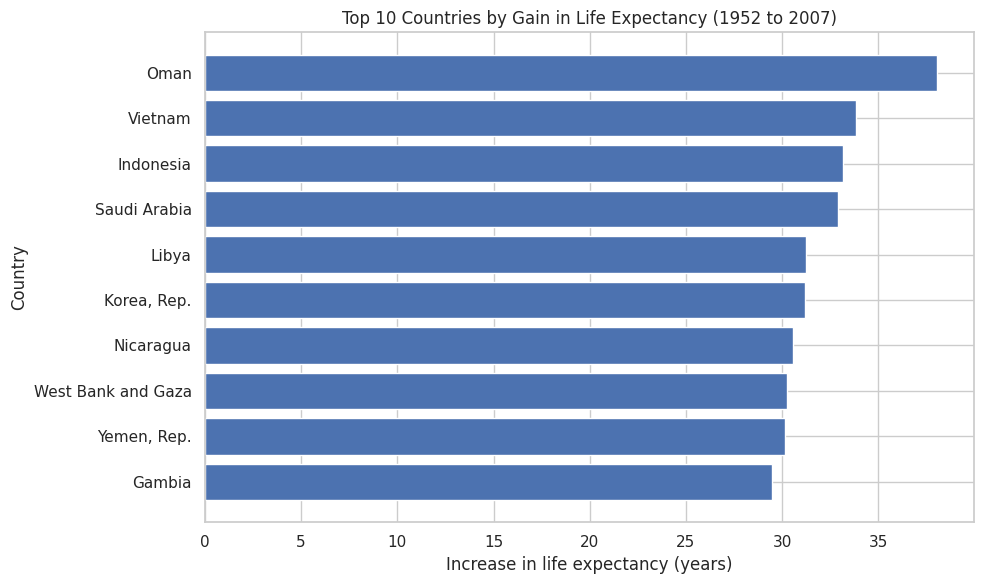

country
Gambia                29.45
Yemen, Rep.           30.15
West Bank and Gaza    30.26
Nicaragua             30.59
Korea, Rep.           31.17
Libya                 31.23
Saudi Arabia          32.90
Indonesia             33.18
Vietnam               33.84
Oman                  38.06
Name: gain, dtype: float64

In [8]:
country_change = (
    df.pivot(index="country", columns="year", values="lifeExp")
      .assign(gain=lambda x: x[2007] - x[1952])
      .sort_values("gain", ascending=False)
)

top_10 = country_change["gain"].head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_10.index, top_10.values)
ax.set_title("Top 10 Countries by Gain in Life Expectancy (1952 to 2007)")
ax.set_xlabel("Increase in life expectancy (years)")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

top_10.round(2)

The country-level view shows that progress was not limited to already-wealthy countries. Oman recorded the largest gain in the dataset, improving life expectancy by about 38.1 years between 1952 and 2007.

That matters because it changes the framing:
- this is not only a story of rich countries staying ahead,
- it is also a story of rapid catch-up in some places,
- though not enough catch-up to eliminate global gaps.

## 8. A quick distribution check: life expectancy shifted upward

A simple histogram helps reinforce the main narrative visually. Comparing the distribution of country-level life expectancy in 1952 and 2007 shows that the entire distribution moved to the right.

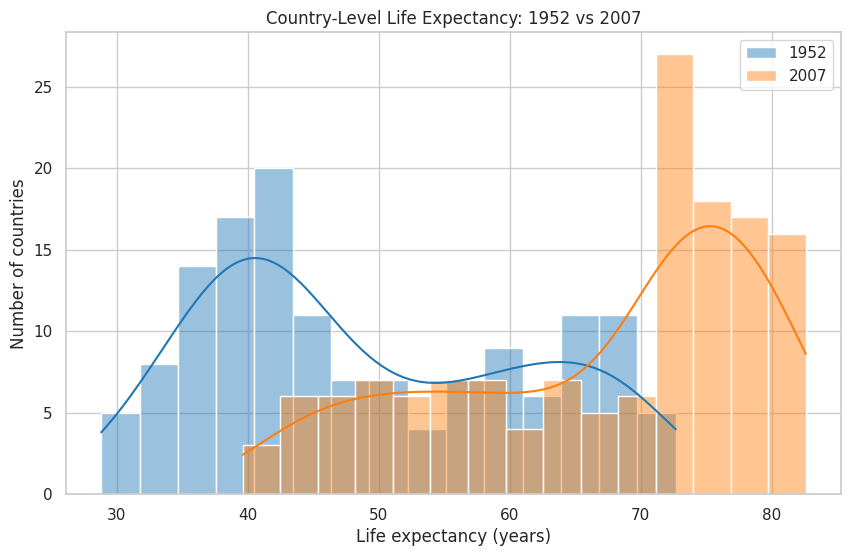

In [9]:
fig, ax = plt.subplots()
sns.histplot(df[df["year"] == 1952]["lifeExp"], color="tab:blue", label="1952", kde=True, bins=15, alpha=0.45, ax=ax)
sns.histplot(df[df["year"] == 2007]["lifeExp"], color="tab:orange", label="2007", kde=True, bins=15, alpha=0.45, ax=ax)
ax.set_title("Country-Level Life Expectancy: 1952 vs 2007")
ax.set_xlabel("Life expectancy (years)")
ax.set_ylabel("Number of countries")
ax.legend()
plt.show()

This distribution view strengthens the earlier conclusion:
- the world did not just improve at the top,
- the whole distribution shifted upward,
- but a meaningful spread still remains across countries.

## 9. Final conclusions

### What can I conclude from these investigations?

1. **Global life expectancy rose substantially from 1952 to 2007.**  
   This is the dominant story in the dataset and a major long-run human development success.

2. **Progress was uneven across regions.**  
   Every continent improved, but the size of the gain differed, showing that development was not equally shared.

3. **Income and life expectancy are strongly linked.**  
   Countries with higher GDP per capita generally have longer lives, especially when moving from low income to middle income.

4. **Country experiences vary widely.**  
   Some countries improved much faster than others, which suggests there are policy, health-system, demographic, and historical factors beyond income alone.

5. **The executive takeaway:**  
   If the goal is to improve human well-being, economic growth matters, but it is not the whole story. The largest opportunities may lie in helping lower-income countries translate growth into broad health gains.

## 10. Limitations and next questions

Important limitations:
- GDP per capita and life expectancy are correlated, but one does not automatically cause the other.
- The dataset is measured at the country level, so it hides within-country inequality.
- Major events such as wars, epidemics, policy reforms, and demographic changes are not modeled directly.

Questions I would ask next:
1. Which countries outperformed their income level on life expectancy, and why?
2. Which countries underperformed despite relatively high income?
3. How did the relationship between GDP and life expectancy change over time?
4. What role might public health investment or education play in explaining the remaining gap?